# K-W test across radiomics features

In [1]:
import os
import glob
from collections import defaultdict
import pandas as pd


def merged_csv(dir_path):
    all_csvs = glob.glob(os.path.join(dir_path, "*", "*spine_vertebrae*.csv"))
    csv_dict = defaultdict(list)
    result_dict = {}
    for file in all_csvs:
        csv_name = os.path.basename(file)
        csv_dict[csv_name].append(file)

    for csv_name, files in csv_dict.items():
        dfs = []
        for file in files:
            df = pd.read_csv(file)
            patient_name = os.path.basename(os.path.dirname(file))
            df.insert(0, "patient", patient_name)
            dfs.append(df)

        key_name = csv_name.replace("_radiomics_spine_vertebrae_features.csv", "")
        big_df = pd.concat(dfs, ignore_index=True)
        result_dict[key_name] = big_df
    return result_dict

In [23]:
from scipy.stats import kruskal
import numpy as np

clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
categoric_features_clinical = ["ISS classification", "M-protein type", "Light chain type"]

all_csvs = merged_csv(r"E:\DATA_Myelomy")
for name, radiomic_df in all_csvs.items():
    print(f"Processing: {name}")

    merged_df = pd.merge(radiomic_df, clinical_df, left_on='patient', right_on='Patient ID')
    numeric_features_image = radiomic_df.select_dtypes(include=['number']).columns

    kruskal_wallis = {}
    for radiomic_col in numeric_features_image:
        data_subset = merged_df[[radiomic_col, "ISS classification"]].dropna()
        groups = [
            group[radiomic_col].values
            for _, group in data_subset.groupby("ISS classification")
        ]

        groups = [g for g in groups if len(g) > 1]

        if len(groups) < 2:
            continue

        all_values = np.concatenate(groups)
        if np.all(all_values == all_values[0]):
            continue

        try:
            stat, p_value = kruskal(*groups)
            kruskal_wallis[radiomic_col] = {'stat': stat, 'p_value': p_value}
        except ValueError:
            continue

    kruskal_wallis_df = pd.DataFrame(kruskal_wallis).T
    kruskal_wallis_df = kruskal_wallis_df.sort_values(by='stat', ascending=False)
    print(f"Significant features: {(kruskal_wallis_df['p_value'] < 0.05).sum()}")
    print(kruskal_wallis_df.head(10))
    print("-" * 50)

Processing: BMD
Significant features: 19
                                                         stat   p_value
original_firstorder_Energy                          11.794678  0.002747
original_firstorder_TotalEnergy                     11.169427  0.003755
gradient_ngtdm_Coarseness                            9.570853  0.008351
original_shape_VoxelVolume                           9.261451  0.009748
gradient_glrlm_RunLengthNonUniformity                9.175249  0.010177
original_shape_MeshVolume                            9.116191  0.010482
original_glrlm_RunLengthNonUniformity                8.514791  0.014159
original_gldm_LargeDependenceHighGrayLevelEmphasis   8.165730  0.016859
gradient_gldm_DependenceNonUniformity                8.016547  0.018165
original_shape_SurfaceVolumeRatio                    7.315546  0.025790
--------------------------------------------------
Processing: CaSupp_25
Significant features: 36
                                            stat   p_value
original_f

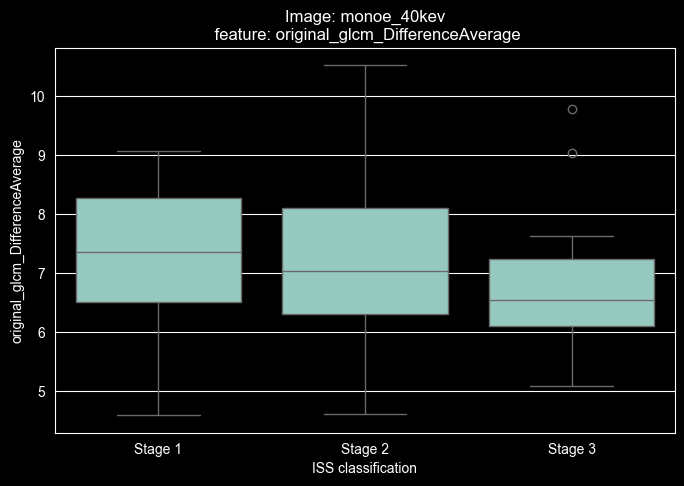

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

image = "monoe_40kev"
feature = "original_glcm_DifferenceAverage"

merged_df = pd.merge(all_csvs[image], clinical_df, left_on='patient', right_on='Patient ID')
plt.figure(figsize=(8, 5))
sns.boxplot(data=merged_df, x="ISS classification", y=feature)
plt.title(f"Image: {image}\n feature: {feature}")
plt.show()

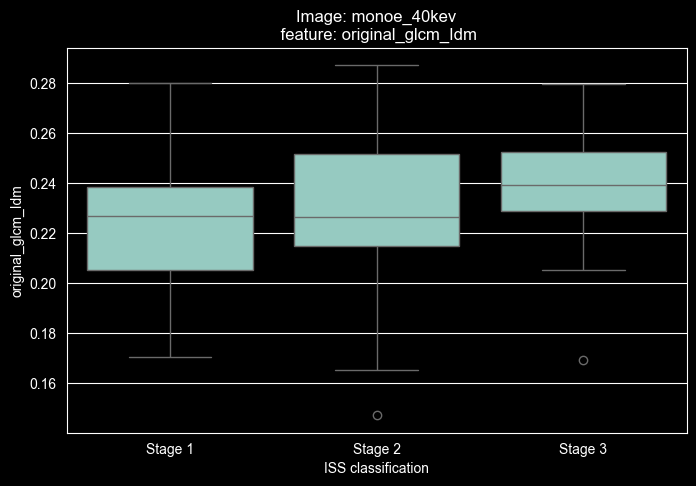

In [25]:
image = "monoe_40kev"
feature = "original_glcm_Idm"

merged_df = pd.merge(all_csvs[image], clinical_df, left_on='patient', right_on='Patient ID')
plt.figure(figsize=(8, 5))
sns.boxplot(data=merged_df, x="ISS classification", y=feature)
plt.title(f"Image: {image}\n feature: {feature}")
plt.show()

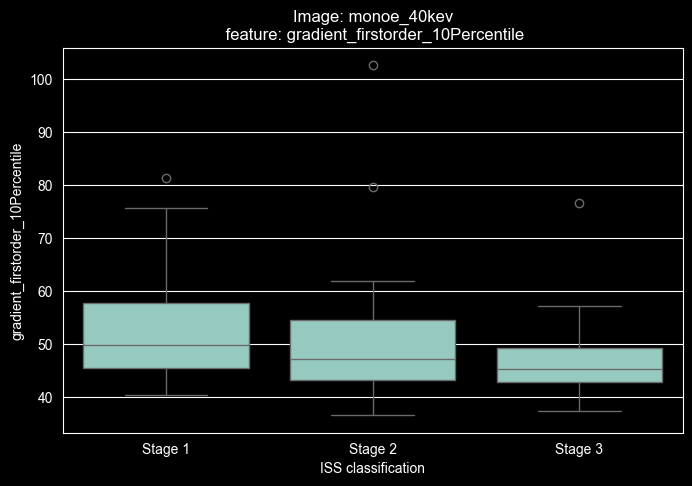

In [26]:
image = "monoe_40kev"
feature = "gradient_firstorder_10Percentile"

merged_df = pd.merge(all_csvs[image], clinical_df, left_on='patient', right_on='Patient ID')
plt.figure(figsize=(8, 5))
sns.boxplot(data=merged_df, x="ISS classification", y=feature)
plt.title(f"Image: {image}\n feature: {feature}")
plt.show()